# Diffusion Model Training (next-day conditional)

Train a conditional diffusion model that learns the next-day IV surface
distribution given the current-day surface,

- historical: consecutive trading days from the chronologically-ordered
  training slice.
- heston / sabr: consecutive simulation steps within paths assigned
  to the training split (paths are disjoint between train and validation).

In [ ]:
# This copies everything INSIDE your input folder INTO the existing working folder
!cp -r /kaggle/input/datasets/sbonelomdluli/ivs-dit/* /kaggle/working/

In [ ]:
!pip install -U pip setuptools wheel
!pip install -e .

In [1]:
import json
import time
from pathlib import Path

import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from implied_volatility_diffusion import (
    ArbitragePenalty,
    ArbitrageWeights,
    DiffusionLoss,
    DiffusionLossConfig,
    DiffusionModel,
    GridTransformer,
    UnifiedGrid,
    VPNoiseScheduler,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "axes.grid": False})


def _select_device() -> torch.device:
    """Prefer Apple Silicon MPS, then CUDA, then CPU."""
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = _select_device()
print(f"compute device: {DEVICE}")

compute device: cuda


In [2]:
%cd /kaggle/working/

/kaggle/working


In [3]:
REPO_ROOT = Path.cwd().resolve()
for _candidate in (REPO_ROOT, *REPO_ROOT.parents):
    if (_candidate / "config").is_dir() and (_candidate / "src").is_dir():
        REPO_ROOT = _candidate
        break
else:
    raise RuntimeError("could not find repository root (expected config/ and src/)")
CFG_DIR = REPO_ROOT / "config"
DATASET_ROOT = Path("/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset")
# CHECKPOINT_DIR = REPO_ROOT / "data" / "processed" / "checkpoints"
# CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

GRID = UnifiedGrid.load(CFG_DIR / "unified_iv_grid.yaml")
print("unified grid:", GRID.shape)

if not (DATASET_ROOT / "manifest.json").exists():
    raise FileNotFoundError(
        f"missing {DATASET_ROOT / 'manifest.json'}; "
        "run notebooks/data/data_pipeline.ipynb first to materialise the training pool"
    )


unified grid: (41, 40)


##  Load training and validation pair stacks

In [4]:
manifest = json.loads((DATASET_ROOT / "manifest.json").read_text())
print("dataset manifest:", json.dumps(manifest, indent=2))

dataset manifest: {
  "sample_date": "2021-06-17",
  "grid": {
    "shape": [
      41,
      40
    ],
    "config": "config/unified_iv_grid.yaml"
  },
  "normalizers": {
    "historic": {
      "path": "data/processed/forecasting_dataset/normalizers/historic.npz",
      "fit_on": "training",
      "n_train_surfaces": 999
    },
    "heston": {
      "path": "data/processed/forecasting_dataset/normalizers/heston.npz",
      "fit_on": "training",
      "n_train_surfaces": 2300
    },
    "sabr": {
      "path": "data/processed/forecasting_dataset/normalizers/sabr.npz",
      "fit_on": "training",
      "n_train_surfaces": 5520
    }
  },
  "sources": {
    "historical": "data/processed/forecasting_dataset/historical",
    "heston": "data/processed/forecasting_dataset/heston",
    "sabr": "data/processed/forecasting_dataset/sabr"
  },
  "splits": {
    "train": "data/processed/forecasting_dataset/training",
    "val": "data/processed/forecasting_dataset/validation",
    "task": "next_da

In [5]:
TRAIN_DIR = "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/training"
VAL_DIR = "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/validation"

In [6]:
# TRAIN_DIR = REPO_ROOT / manifest["splits"]["train"]
# VAL_DIR = REPO_ROOT / manifest["splits"]["val"]
normalizer_stats = np.load(DATASET_ROOT / "normalizer.npz")
normalizer_mean = normalizer_stats["mean"].astype(np.float32)
normalizer_std = normalizer_stats["std"].astype(np.float32)
normalizer_iv_floor = float(normalizer_stats.get("iv_floor", 1e-8))
normalizer_stats.close()


#  Training pair stack
pair_curr = np.load(
    "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/training/pair_curr.npy"
).astype(np.float32)  # S_t
pair_next = np.load(
    "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/training/pair_next.npy"
).astype(np.float32)  # S_{t+1}
training_sources = np.load(
    "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/training/pair_sources.npy"
)
assert pair_curr.shape == pair_next.shape, f"train curr/next shape mismatch: {pair_curr.shape} vs {pair_next.shape}"
n_total = int(pair_curr.shape[0])

#  Validation pair stack (held out, not used to update weights)
val_pair_curr = np.load(
    "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/validation/pair_curr.npy"
).astype(np.float32)
val_pair_next = np.load(
    "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/validation/pair_next.npy"
).astype(np.float32)
val_pair_sources = np.load(
    "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/validation/pair_sources.npy"
)
assert val_pair_curr.shape == val_pair_next.shape


historic_surfaces = np.load(
    "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/historical/surfaces.npy"
)
heston_surfaces = np.load(
    "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/heston/surfaces.npy"
)  # (n_paths, n_steps, K, T)
sabr_surfaces = np.load(
    "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/sabr/surfaces.npy"
)  # (n_paths, n_steps, K, T)

historic_dates = pd.DatetimeIndex(
    np.load("/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/historical/dates.npy")
)
val_hist_curr_dates = pd.DatetimeIndex(
    np.load(
        "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/validation/historical_curr_dates.npy"
    )
)
val_hist_next_dates = pd.DatetimeIndex(
    np.load(
        "/kaggle/input/datasets/sbonelomdluli/ivs-training/forecasting_dataset/validation/historical_next_dates.npy"
    )
)

In [21]:
NUM_EPOCHS = 50
BATCH_SIZE = 32
LR = 2e-4
GRAD_CLIP = 1.0

SCHEDULER_TIMESTEPS = 400
ARBITRAGE_LAMBDA = 0.05
ARBITRAGE_SCHEDULE = "alpha_bar"

SMOOTHNESS_LAMBDA = 1e-3
SMOOTHNESS_SCHEDULE = "alpha_bar"
EPS_LOSS_SCHEDULE = "alpha_bar"
SNR_WEIGHTING = False
SEED = 42


WEIGHT_DECAY = 1e-2
WARMUP_FRAC = 0.03
LR_FLOOR_FRAC = 0.05
EMA_DECAY = 0.999
EMA_WARMUP_STEPS = 100
VAL_FRAC = 0.20
VAL_BATCH_CAP = 1024
STRATIFIED_BATCHES = True
INPUT_NOISE_STD_Z = 0.0
LOG_EVERY_N_STEPS = 50


# Higher-capacity GridTransformer (closer effective capacity to the U-Net backbone in
# unet_diffusion_model_training.ipynb: wider tokens, deeper stack, larger FFN).
GRID_TRANSFORMER_KWARGS = dict(
    grid_shape=tuple(GRID.shape),
    in_channels=1,
    out_channels=1,
    cond_channels=1,
    d_model=256,
    nhead=8,
    layers=8,
    dim_feedforward=1536,
    dropout=0.1,
    time_embedding_dim=256,
)

SPOT_REF = 100.0
RATE_REF = 0.03

SNAPSHOT_T_VALUES = (10, 100, 250, 380)
N_SNAPSHOT_EPOCHS = 4

steps_per_epoch = max(int(np.ceil(n_total / BATCH_SIZE)), 1)
total_steps = NUM_EPOCHS * steps_per_epoch
warmup_steps = max(1, int(round(total_steps * WARMUP_FRAC)))

## Trainig config

## Build model, scheduler, loss and optimiser

In [22]:
torch.manual_seed(SEED)

scheduler = VPNoiseScheduler(timesteps=SCHEDULER_TIMESTEPS, beta_schedule="cosine")
backbone = GridTransformer(**GRID_TRANSFORMER_KWARGS)
model = DiffusionModel(
    backbone,
    scheduler,
    mean=normalizer_mean,
    std=normalizer_std,
    iv_floor=normalizer_iv_floor,
).to(DEVICE)


penalty = ArbitragePenalty(
    log_moneyness=GRID.log_moneyness,
    tau=GRID.tau,
    spot=SPOT_REF,
    rate=RATE_REF,
    weights=ArbitrageWeights(),
)


loss_fn = DiffusionLoss(
    penalty,
    config=DiffusionLossConfig(
        arbitrage_lambda=ARBITRAGE_LAMBDA,
        arbitrage_schedule=ARBITRAGE_SCHEDULE,
        smoothness_lambda=SMOOTHNESS_LAMBDA,
        smoothness_schedule=SMOOTHNESS_SCHEDULE,
        snr_weighting=SNR_WEIGHTING,
        eps_loss_schedule=EPS_LOSS_SCHEDULE,
    ),
).to(DEVICE)

In [23]:
def _split_params_for_decay(module: torch.nn.Module) -> tuple[list, list]:
    decay, no_decay = [], []
    for name, p in module.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or name.endswith(".bias"):
            no_decay.append(p)
        else:
            decay.append(p)
    return decay, no_decay


_decay_params, _no_decay_params = _split_params_for_decay(model)
optimizer = torch.optim.AdamW(
    [
        {"params": _decay_params, "weight_decay": WEIGHT_DECAY},
        {"params": _no_decay_params, "weight_decay": 0.0},
    ],
    lr=LR,
    betas=(0.9, 0.999),
    eps=1e-8,
)


def _make_lr_schedule(
    optimizer: torch.optim.Optimizer,
    *,
    total_steps: int,
    warmup_steps: int,
    floor_frac: float,
) -> torch.optim.lr_scheduler.LambdaLR:
    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        progress = min(max(progress, 0.0), 1.0)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return floor_frac + (1.0 - floor_frac) * cosine

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


lr_scheduler = _make_lr_schedule(
    optimizer,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    floor_frac=LR_FLOOR_FRAC,
)


class _EmaShadow:
    """Lightweight EMA over a model's parameters and buffers.

    ``decay`` is the smoothing factor (closer to 1 -> slower averaging).
    Buffers are tracked too so the EMA copy can be loaded directly without
    recomputing per-pixel normalization stats.
    """

    def __init__(
        self,
        module: torch.nn.Module,
        *,
        decay: float = 0.999,
        warmup_steps: int = 0,
    ) -> None:
        self.decay = float(decay)
        self.warmup_steps = int(warmup_steps)
        self._step = 0
        self.shadow_module = copy.deepcopy(module).eval()
        for p in self.shadow_module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, module: torch.nn.Module) -> None:
        self._step += 1
        # Linear warmup of the effective decay so the early shadow tracks the
        # live model (avoids "EMA stuck near init" for the first epoch).
        d = min(self.decay, (self._step + 1) / (self._step + 10)) if self._step <= self.warmup_steps else self.decay
        live_params = dict(module.named_parameters())
        live_buffers = dict(module.named_buffers())
        for name, p_shadow in self.shadow_module.named_parameters():
            p_live = live_params.get(name)
            if p_live is None:
                continue
            p_shadow.data.mul_(d).add_(p_live.data, alpha=1.0 - d)
        for name, b_shadow in self.shadow_module.named_buffers():
            b_live = live_buffers.get(name)
            if b_live is None:
                continue
            if b_shadow.dtype.is_floating_point:
                b_shadow.data.mul_(d).add_(b_live.data, alpha=1.0 - d)
            else:
                b_shadow.data.copy_(b_live.data)


ema = _EmaShadow(model, decay=EMA_DECAY, warmup_steps=EMA_WARMUP_STEPS)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

##  Held-out denoising (conditional)

In [24]:
# select a historical (S_t, S_{t+1}) pair
val_hist_mask = val_pair_sources == 0
val_hist_indices = np.flatnonzero(val_hist_mask)
holdout_val_idx = int(val_hist_indices[-1])

holdout_curr_np = val_pair_curr[holdout_val_idx].astype(np.float32)
holdout_next_np = val_pair_next[holdout_val_idx].astype(np.float32)

holdout_curr = torch.tensor(holdout_curr_np, dtype=torch.float32, device=DEVICE)[None, None]
holdout_next = torch.tensor(holdout_next_np, dtype=torch.float32, device=DEVICE)[None, None]

In [25]:
# Translate the val_hist row index to the underlying historical date pair.
hist_val_pos = int(np.searchsorted(val_hist_indices, holdout_val_idx))
holdout_curr_date = val_hist_curr_dates[hist_val_pos]
holdout_next_date = val_hist_next_dates[hist_val_pos]
snapshot_t = torch.tensor(SNAPSHOT_T_VALUES, dtype=torch.long, device=DEVICE).clamp(max=scheduler.timesteps - 1)

snapshot_generator = torch.Generator().manual_seed(SEED)
holdout_z0_next = model.normalize(holdout_next)
holdout_cond_z = model.normalize(holdout_curr)
holdout_eps = torch.randn(
    (snapshot_t.shape[0], *holdout_z0_next.shape[1:]),
    generator=snapshot_generator,
).to(DEVICE)
holdout_z_t = scheduler.q_sample(
    holdout_z0_next.expand(snapshot_t.shape[0], -1, -1, -1).contiguous(),
    snapshot_t,
    noise=holdout_eps,
)
holdout_cond_z_batched = holdout_cond_z.expand(snapshot_t.shape[0], -1, -1, -1).contiguous()

epochs_for_snapshots = sorted(set(int(round(v)) for v in np.linspace(1, NUM_EPOCHS, N_SNAPSHOT_EPOCHS).tolist()))
print(f"snapshot epochs: {epochs_for_snapshots}")
print(f"snapshot timesteps: {snapshot_t.tolist()}")

snapshot epochs: [1, 17, 34, 50]
snapshot timesteps: [10, 100, 250, 380]


## Model training

In [26]:
training_tensor_next = torch.from_numpy(pair_next).unsqueeze(1)
training_tensor_curr = torch.from_numpy(pair_curr).unsqueeze(1)
PIN_MEMORY = DEVICE.type == "cuda"
if PIN_MEMORY:
    training_tensor_next = training_tensor_next.pin_memory()
    training_tensor_curr = training_tensor_curr.pin_memory()

#   - Train / val split (stratified by source)
val_rng = np.random.default_rng(SEED + 999)
val_idx_list: list[np.ndarray] = []
for src_id in np.unique(training_sources):
    where = np.flatnonzero(training_sources == src_id)
    n_val_src = max(1, int(round(len(where) * VAL_FRAC))) if VAL_FRAC > 0 else 0
    if n_val_src > 0:
        chosen = val_rng.choice(where, size=n_val_src, replace=False)
        val_idx_list.append(chosen)
val_indices = np.sort(np.concatenate(val_idx_list)) if val_idx_list else np.empty(0, dtype=np.int64)
val_mask = np.zeros(n_total, dtype=bool)
val_mask[val_indices] = True
train_indices = np.flatnonzero(~val_mask)
train_sources_ = training_sources[train_indices]
n_train = int(train_indices.shape[0])
n_val = int(val_indices.shape[0])
print(f"train/val split: train={n_train}  val={n_val}  (val_frac={VAL_FRAC})")

src_buckets: dict[int, np.ndarray] = {
    int(src): train_indices[np.flatnonzero(train_sources_ == src)] for src in np.unique(train_sources_)
}
src_quotas = {
    src_id: max(1, int(round(BATCH_SIZE * len(idxs) / max(1, n_train)))) for src_id, idxs in src_buckets.items()
}


def _stratified_batch_indices(rng_: np.random.Generator) -> np.ndarray:
    """Sample one batch with per-source quotas (with replacement within source)."""
    chunks: list[np.ndarray] = []
    for src_id, idxs in src_buckets.items():
        if idxs.size == 0:
            continue
        chunks.append(
            rng_.choice(idxs, size=src_quotas[src_id], replace=False if idxs.size >= src_quotas[src_id] else True)
        )
    if not chunks:
        return np.empty(0, dtype=np.int64)
    return np.concatenate(chunks)


arb_family_names = ["calendar", "butterfly", "call"]

step_history: dict[str, list[float | int]] = {
    "step": [],
    "epoch": [],
    "loss": [],
    "loss_eps": [],
    "loss_smooth": [],
    "loss_arb": [],
    "grad_norm": [],
    "lr": [],
    "arb_weight_mean": [],
    "skipped_nonfinite": [],
}
for name in arb_family_names:
    step_history[f"arb_{name}"] = []

epoch_history: list[dict[str, float]] = []
snapshots: list[dict[str, np.ndarray | int]] = []


def _validation_loss(model_to_eval: torch.nn.Module) -> dict[str, float]:
    """Mean eps MSE + smoothness + arbitrage on the held-out validation slice."""
    if n_val == 0:
        return {
            "val_loss": float("nan"),
            "val_loss_eps": float("nan"),
            "val_loss_smooth": float("nan"),
            "val_loss_arb": float("nan"),
        }
    val_rng_local = torch.Generator().manual_seed(SEED + 1234)
    chunks: list[dict[str, float]] = []
    model_to_eval.eval()
    with torch.no_grad():
        for vb_start in range(0, n_val, BATCH_SIZE):
            v_idx = val_indices[vb_start : vb_start + BATCH_SIZE]
            v_iv_next = training_tensor_next[v_idx].to(DEVICE, non_blocking=PIN_MEMORY)
            v_iv_curr = training_tensor_curr[v_idx].to(DEVICE, non_blocking=PIN_MEMORY)
            v_cond_z = model_to_eval.normalize(v_iv_curr)
            v_t = loss_fn.sample_timesteps(
                v_iv_next.shape[0],
                scheduler,
                device=DEVICE,
                generator=val_rng_local,
            )
            v_noise = torch.randn(v_iv_next.shape, generator=val_rng_local).to(DEVICE)
            v_out = loss_fn(model_to_eval, v_iv_next, t=v_t, noise=v_noise, cond=v_cond_z)
            chunks.append(
                {
                    "loss": float(v_out["loss"].detach()),
                    "loss_eps": float(v_out["loss_eps"].detach()),
                    "loss_smooth": float(v_out.get("loss_smooth", torch.zeros(1)).detach()),
                    "loss_arb": float(v_out.get("loss_arb", torch.zeros(1)).detach()),
                    "n": v_iv_next.shape[0],
                }
            )
    if not chunks:
        return {
            "val_loss": float("nan"),
            "val_loss_eps": float("nan"),
            "val_loss_smooth": float("nan"),
            "val_loss_arb": float("nan"),
        }
    total_n = sum(c["n"] for c in chunks)
    return {
        "val_loss": sum(c["loss"] * c["n"] for c in chunks) / total_n,
        "val_loss_eps": sum(c["loss_eps"] * c["n"] for c in chunks) / total_n,
        "val_loss_smooth": sum(c["loss_smooth"] * c["n"] for c in chunks) / total_n,
        "val_loss_arb": sum(c["loss_arb"] * c["n"] for c in chunks) / total_n,
    }

train/val split: train=6999  val=1750  (val_frac=0.2)


train model

In [27]:
steps_per_epoch_train = max(int(np.ceil(n_train / BATCH_SIZE)), 1)
total_steps_train = NUM_EPOCHS * steps_per_epoch_train

rng = np.random.default_rng(SEED)
global_step = 0
nonfinite_skips = 0
best_val = float("inf")
best_state = None
best_epoch = 0
model.train()
t0 = time.perf_counter()

epoch_progress = tqdm(range(1, NUM_EPOCHS + 1), desc="Training epochs", unit="epoch")
for epoch in epoch_progress:
    perm = rng.permutation(n_train)
    epoch_losses: list[float] = []
    epoch_loss_eps: list[float] = []
    epoch_loss_smooth: list[float] = []
    epoch_loss_arb: list[float] = []
    epoch_skipped = 0
    batch_progress = tqdm(
        range(0, n_train, BATCH_SIZE),
        desc=f"Epoch {epoch}/{NUM_EPOCHS}",
        unit="batch",
        leave=False,
    )
    for batch_start in batch_progress:
        if STRATIFIED_BATCHES:
            idx = _stratified_batch_indices(rng)
        else:
            idx = train_indices[perm[batch_start : batch_start + BATCH_SIZE]]
        if idx.size == 0:
            continue
        batch_iv_next = training_tensor_next[idx].to(DEVICE, non_blocking=PIN_MEMORY)
        batch_iv_curr = training_tensor_curr[idx].to(DEVICE, non_blocking=PIN_MEMORY)
        with torch.no_grad():
            cond_z = model.normalize(batch_iv_curr)

        # Optional small jitter in *normalized* target space simulates calibration
        # noise and acts as input dropout regularisation.
        if INPUT_NOISE_STD_Z > 0.0:
            with torch.no_grad():
                z_clean = model.normalize(batch_iv_next)
                z_jit = z_clean + INPUT_NOISE_STD_Z * torch.randn_like(z_clean)
                batch_iv_next = model.denormalize(z_jit)

        optimizer.zero_grad(set_to_none=True)
        out = loss_fn(model, batch_iv_next, cond=cond_z)
        loss_value = out["loss"]

        if not torch.isfinite(loss_value):
            optimizer.zero_grad(set_to_none=True)
            nonfinite_skips += 1
            epoch_skipped += 1
            global_step += 1
            lr_scheduler.step()
            continue

        loss_value.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        if not torch.isfinite(grad_norm):
            optimizer.zero_grad(set_to_none=True)
            nonfinite_skips += 1
            epoch_skipped += 1
            global_step += 1
            lr_scheduler.step()
            continue

        optimizer.step()
        lr_scheduler.step()
        ema.update(model)

        step_loss = float(out["loss"].detach())
        step_loss_eps = float(out["loss_eps"].detach())
        step_loss_smooth = float(out.get("loss_smooth", torch.zeros(1)).detach())
        step_loss_arb = float(out.get("loss_arb", torch.zeros(1)).detach())
        cur_lr = float(optimizer.param_groups[0]["lr"])

        step_history["step"].append(global_step)
        step_history["epoch"].append(epoch)
        step_history["loss"].append(step_loss)
        step_history["loss_eps"].append(step_loss_eps)
        step_history["loss_smooth"].append(step_loss_smooth)
        step_history["loss_arb"].append(step_loss_arb)
        step_history["grad_norm"].append(float(grad_norm))
        step_history["lr"].append(cur_lr)
        step_history["arb_weight_mean"].append(float(out.get("arb_weight_mean", torch.zeros(1)).detach()))
        step_history["skipped_nonfinite"].append(0)
        for name in arb_family_names:
            step_history[f"arb_{name}"].append(float(out.get(f"arb_{name}", torch.zeros(1)).detach()))

        epoch_losses.append(step_loss)
        epoch_loss_eps.append(step_loss_eps)
        epoch_loss_smooth.append(step_loss_smooth)
        epoch_loss_arb.append(step_loss_arb)
        global_step += 1

        if LOG_EVERY_N_STEPS > 0 and (global_step % LOG_EVERY_N_STEPS == 0):
            print(
                f"    step {global_step:>5d}  loss={step_loss:.4f}  "
                f"eps={step_loss_eps:.4f}  smth={step_loss_smooth:.4f}  arb={step_loss_arb:.4f}  "
                f"grad={float(grad_norm):.3f}  lr={cur_lr:.2e}"
            )

    val_metrics = _validation_loss(ema.shadow_module if EMA_DECAY > 0 else model)
    model.train()

    epoch_summary = {
        "epoch": epoch,
        "loss_mean": float(np.mean(epoch_losses)) if epoch_losses else float("nan"),
        "loss_eps_mean": float(np.mean(epoch_loss_eps)) if epoch_loss_eps else float("nan"),
        "loss_smooth_mean": float(np.mean(epoch_loss_smooth)) if epoch_loss_smooth else float("nan"),
        "loss_arb_mean": float(np.mean(epoch_loss_arb)) if epoch_loss_arb else float("nan"),
        "skipped_nonfinite_epoch": int(epoch_skipped),
        "elapsed_s": time.perf_counter() - t0,
        **val_metrics,
    }
    epoch_history.append(epoch_summary)
    epoch_progress.set_postfix(
        loss=f"{epoch_summary['loss_mean']:.4f}",
        val=f"{epoch_summary['val_loss']:.4f}",
        skip=int(epoch_skipped),
    )
    print(
        f"  epoch {epoch:>2d}/{NUM_EPOCHS}  "
        f"loss={epoch_summary['loss_mean']:.4f}  "
        f"eps={epoch_summary['loss_eps_mean']:.4f}  "
        f"smth={epoch_summary['loss_smooth_mean']:.4f}  "
        f"arb={epoch_summary['loss_arb_mean']:.4f}  "
        f"val={epoch_summary['val_loss']:.4f}  "
        f"skip={epoch_skipped}  "
        f"({epoch_summary['elapsed_s']:.0f}s)"
    )

    if n_val > 0 and np.isfinite(val_metrics["val_loss"]) and val_metrics["val_loss"] < best_val:
        best_val = float(val_metrics["val_loss"])
        best_epoch = epoch
        best_state = copy.deepcopy(ema.shadow_module.state_dict())

    if epoch in epochs_for_snapshots:
        eval_module = ema.shadow_module if EMA_DECAY > 0 else model
        eval_module.eval()
        with torch.no_grad():
            iv_pred = eval_module.predict_iv(holdout_z_t, snapshot_t, holdout_cond_z_batched)
        snapshots.append(
            {
                "epoch": epoch,
                "step": global_step,
                "iv_pred": iv_pred.squeeze(1).cpu().numpy(),
            }
        )
        model.train()

Training epochs:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50:   0%|          | 0/219 [00:00<?, ?batch/s]

    step    50  loss=0.1184  eps=0.0876  smth=0.7078  arb=0.6009  grad=2.771  lr=2.48e-05
    step   100  loss=0.0373  eps=0.0140  smth=0.3448  arb=0.4591  grad=1.621  lr=4.91e-05
    step   150  loss=0.0371  eps=0.0103  smth=0.4026  arb=0.5295  grad=0.929  lr=7.35e-05
    step   200  loss=0.0279  eps=0.0076  smth=0.3809  arb=0.3990  grad=0.715  lr=9.78e-05
  epoch  1/50  loss=0.2526  eps=0.2248  smth=0.5146  arb=0.5468  val=0.0390  skip=0  (54s)


Epoch 2/50:   0%|          | 0/219 [00:00<?, ?batch/s]

    step   250  loss=0.0363  eps=0.0207  smth=0.1844  arb=0.3098  grad=2.949  lr=1.22e-04
    step   300  loss=0.0266  eps=0.0105  smth=0.1035  arb=0.3194  grad=1.632  lr=1.46e-04
    step   350  loss=0.0285  eps=0.0124  smth=0.1367  arb=0.3192  grad=2.215  lr=1.71e-04
    step   400  loss=0.0369  eps=0.0260  smth=0.0822  arb=0.2149  grad=2.499  lr=1.95e-04
  epoch  2/50  loss=0.0276  eps=0.0130  smth=0.1686  arb=0.2898  val=0.0338  skip=0  (109s)


...

    step 10300  loss=0.0153  eps=0.0045  smth=0.0419  arb=0.2150  grad=0.081  lr=3.91e-05
    step 10350  loss=0.0226  eps=0.0087  smth=0.0848  arb=0.2760  grad=0.073  lr=3.83e-05
    step 10400  loss=0.0183  eps=0.0072  smth=0.0552  arb=0.2211  grad=0.137  lr=3.75e-05
    step 10450  loss=0.0137  eps=0.0045  smth=0.0393  arb=0.1835  grad=0.100  lr=3.67e-05
    step 10500  loss=0.0262  eps=0.0119  smth=0.0850  arb=0.2842  grad=0.064  lr=3.59e-05
  epoch 48/50  loss=0.0175  eps=0.0067  smth=0.0589  arb=0.2142  val=0.0170  skip=0  (2624s)


Epoch 49/50:   0%|          | 0/219 [00:00<?, ?batch/s]

    step 10550  loss=0.0165  eps=0.0050  smth=0.0469  arb=0.2299  grad=0.077  lr=3.51e-05
    step 10600  loss=0.0170  eps=0.0074  smth=0.0730  arb=0.1907  grad=0.342  lr=3.44e-05
    step 10650  loss=0.0155  eps=0.0054  smth=0.0394  arb=0.2029  grad=0.372  lr=3.36e-05
    step 10700  loss=0.0179  eps=0.0057  smth=0.0418  arb=0.2434  grad=0.175  lr=3.29e-05
  epoch 49/50  loss=0.0173  eps=0.0066  smth=0.0580  arb=0.2125  val=0.0170  skip=0  (2679s)


Epoch 50/50:   0%|          | 0/219 [00:00<?, ?batch/s]

    step 10750  loss=0.0133  eps=0.0042  smth=0.0402  arb=0.1810  grad=0.244  lr=3.22e-05
    step 10800  loss=0.0217  eps=0.0072  smth=0.0682  arb=0.2893  grad=0.147  lr=3.15e-05
    step 10850  loss=0.0140  eps=0.0053  smth=0.0436  arb=0.1735  grad=0.037  lr=3.08e-05
    step 10900  loss=0.0175  eps=0.0065  smth=0.0542  arb=0.2181  grad=0.096  lr=3.01e-05
    step 10950  loss=0.0179  eps=0.0057  smth=0.0545  arb=0.2421  grad=0.092  lr=2.94e-05
  epoch 50/50  loss=0.0169  eps=0.0063  smth=0.0565  arb=0.2103  val=0.0170  skip=0  (2733s)


In [28]:
if best_state is not None:
    print(f"loading best EMA checkpoint from epoch {best_epoch} (val_loss={best_val:.4f})")
    model.load_state_dict(best_state)
elif EMA_DECAY > 0:
    print("loading final EMA checkpoint into the live model.")
    model.load_state_dict(ema.shadow_module.state_dict())

step_history_df = pd.DataFrame(step_history)
epoch_history_df = pd.DataFrame(epoch_history)
print(
    f"trained {global_step} steps across {NUM_EPOCHS} epochs in "
    f"{time.perf_counter() - t0:.1f}s  (skipped non-finite={nonfinite_skips})"
)
print(epoch_history_df.to_string(index=False))

loading best EMA checkpoint from epoch 50 (val_loss=0.0170)
trained 10950 steps across 50 epochs in 2733.2s  (skipped non-finite=0)
 epoch  loss_mean  loss_eps_mean  loss_smooth_mean  loss_arb_mean  skipped_nonfinite_epoch   elapsed_s  val_loss  val_loss_eps  val_loss_smooth  val_loss_arb
     1   0.252634       0.224781          0.514555       0.546770                        0   54.229412  0.038974      0.014529         0.448793      0.479921
     2   0.027615       0.012956          0.168638       0.289807                        0  108.580840  0.033761      0.010703         0.409159      0.452977
     3   0.022631       0.010388          0.097969       0.242885                        0  163.245311  0.030017      0.008168         0.369607      0.429578
     4   0.021661       0.010012          0.088568       0.231227                        0  218.137857  0.027118      0.006747         0.314590      0.401144
     5   0.021910       0.010286          0.080482       0.230875             

## plots

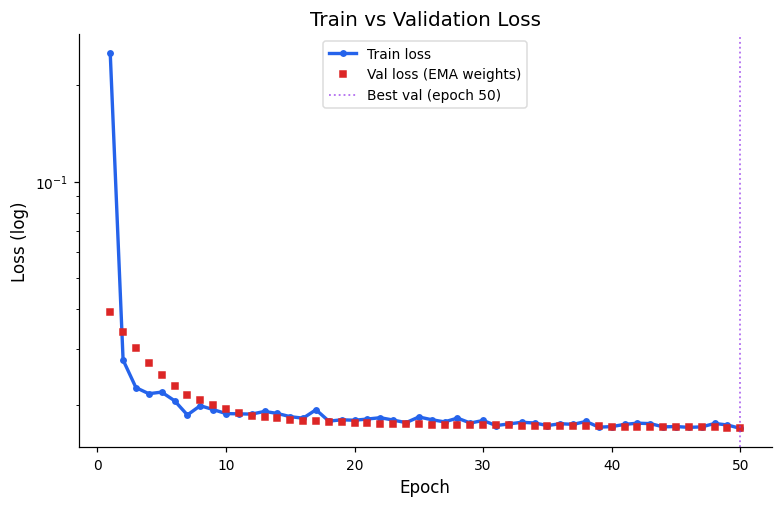

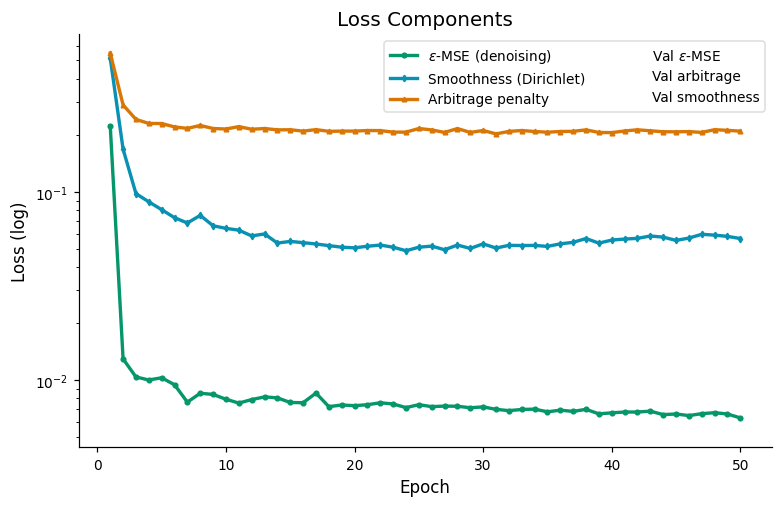

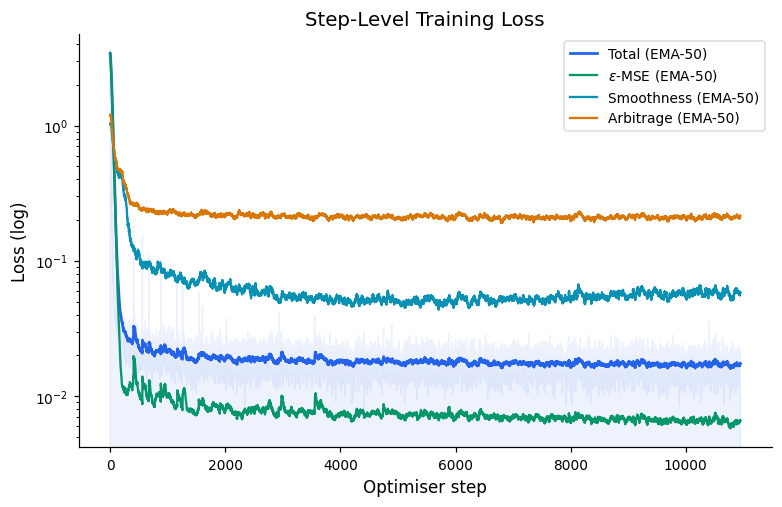

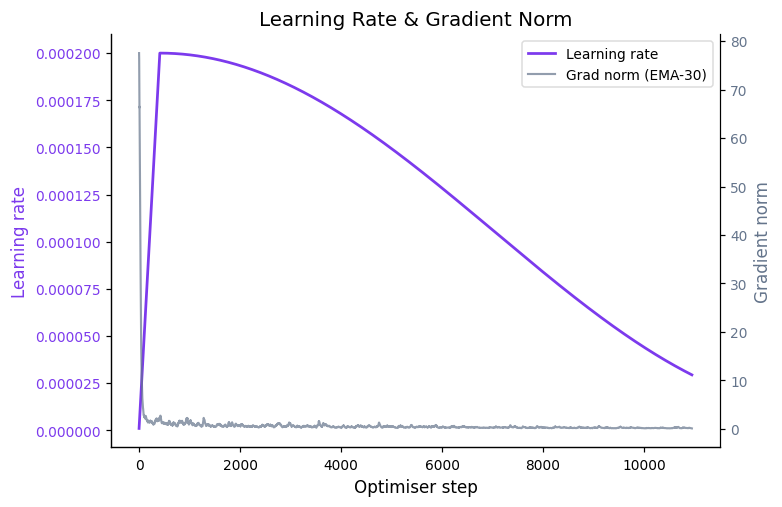

In [29]:
def _ema(series: np.ndarray, span: int = 50) -> np.ndarray:
    return pd.Series(series).ewm(span=span, adjust=False).mean().to_numpy()


_STYLE = {
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "0.85",
}

with plt.rc_context(_STYLE):
    epochs = epoch_history_df["epoch"].to_numpy()
    steps_arr = step_history_df["step"].to_numpy()

    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    ax.plot(
        epochs, epoch_history_df["loss_mean"], lw=2.2, color="#2563eb", marker="o", markersize=3.5, label="Train loss"
    )
    if "val_loss" in epoch_history_df.columns and epoch_history_df["val_loss"].notna().any():
        ax.plot(
            epochs,
            epoch_history_df["val_loss"],
            lw=2.2,
            color="#dc2626",
            marker="s",
            markersize=3.5,
            linestyle=" ",
            label="Val loss (EMA weights)",
        )
    if best_epoch > 0:
        ax.axvline(best_epoch, color="#9333ea", ls=":", lw=1.2, alpha=0.7, label=f"Best val (epoch {best_epoch})")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Train vs Validation Loss")
    ax.legend()
    ax.grid(alpha=0.15, which="both", ls=" ")
    fig.savefig("training_loss_train_vs_val.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    ax.plot(
        epochs,
        epoch_history_df["loss_eps_mean"],
        lw=2.2,
        color="#059669",
        marker="o",
        markersize=3,
        label=r"$\epsilon$-MSE (denoising)",
    )
    ax.plot(
        epochs,
        epoch_history_df["loss_smooth_mean"],
        lw=2.2,
        color="#0891b2",
        marker="d",
        markersize=3,
        label="Smoothness (Dirichlet)",
    )
    ax.plot(
        epochs,
        epoch_history_df["loss_arb_mean"],
        lw=2.2,
        color="#d97706",
        marker="^",
        markersize=3,
        label="Arbitrage penalty",
    )
    if "val_loss_eps" in epoch_history_df.columns:
        ax.plot(
            epochs,
            epoch_history_df["val_loss_eps"],
            lw=1.6,
            color="#059669",
            ls=" ",
            alpha=0.65,
            label=r"Val $\epsilon$-MSE",
        )
    if "val_loss_arb" in epoch_history_df.columns:
        ax.plot(
            epochs,
            epoch_history_df["val_loss_arb"],
            lw=1.6,
            color="#d97706",
            ls=" ",
            alpha=0.65,
            label="Val arbitrage",
        )
    if "val_loss_smooth" in epoch_history_df.columns:
        ax.plot(
            epochs,
            epoch_history_df["val_loss_smooth"],
            lw=1.6,
            color="#0891b2",
            ls=" ",
            alpha=0.65,
            label="Val smoothness",
        )
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Loss Components")
    ax.legend(ncols=2)
    ax.grid(alpha=0.15, which="both", ls=" ")
    fig.savefig("training_loss_components.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    ax.fill_between(steps_arr, step_history_df["loss"], alpha=0.08, color="#2563eb")
    ax.plot(steps_arr, _ema(step_history_df["loss"].to_numpy()), lw=1.8, color="#2563eb", label="Total (EMA-50)")
    ax.plot(
        steps_arr,
        _ema(step_history_df["loss_eps"].to_numpy()),
        lw=1.5,
        color="#059669",
        label=r"$\epsilon$-MSE (EMA-50)",
    )
    ax.plot(
        steps_arr,
        _ema(step_history_df["loss_smooth"].to_numpy()),
        lw=1.5,
        color="#0891b2",
        label="Smoothness (EMA-50)",
    )
    ax.plot(
        steps_arr, _ema(step_history_df["loss_arb"].to_numpy()), lw=1.5, color="#d97706", label="Arbitrage (EMA-50)"
    )
    ax.set_yscale("log")
    ax.set_xlabel("Optimiser step")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Step-Level Training Loss")
    ax.legend()
    ax.grid(alpha=0.15, which="both", ls=" ")
    fig.savefig("training_loss_step_level.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    color_lr, color_gn = "#7c3aed", "#64748b"
    ax.plot(steps_arr, step_history_df["lr"], lw=1.8, color=color_lr, label="Learning rate")
    ax.set_xlabel("Optimiser step")
    ax.set_ylabel("Learning rate", color=color_lr)
    ax.tick_params(axis="y", labelcolor=color_lr)
    ax.grid(alpha=0.15, which="both", ls=" ")

    ax2 = ax.twinx()
    ax2.plot(
        steps_arr,
        _ema(step_history_df["grad_norm"].to_numpy(), span=30),
        lw=1.4,
        color=color_gn,
        alpha=0.7,
        label="Grad norm (EMA-30)",
    )
    ax2.set_ylabel("Gradient norm", color=color_gn)
    ax2.tick_params(axis="y", labelcolor=color_gn)
    ax2.spines["right"].set_visible(True)
    ax2.spines["top"].set_visible(False)
    ax.set_title("Learning Rate & Gradient Norm")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    fig.savefig("training_loss_lr_grad_norm.pdf", format="pdf", bbox_inches="tight")
    plt.show()

## Save checkpoint

Persist the trained weights, optimiser state, loss histories

In [30]:
!mkdir -p /kaggle/working/checkpoints

In [31]:
CHECKPOINT_DIR = "/kaggle/working/"

In [32]:
checkpoint_path = Path("/kaggle/working/diffusion_grid_transformer.pt")
config_path = Path("/kaggle/working/training_config.json")
step_csv_path = Path("/kaggle/working/training_step_history.csv")
epoch_csv_path = Path("/kaggle/working/training_epoch_history.csv")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_timesteps": SCHEDULER_TIMESTEPS,
        "backbone": "grid_transformer",
        "transformer_kwargs": GRID_TRANSFORMER_KWARGS,
        "grid_shape": tuple(GRID.shape),
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "arbitrage_lambda": ARBITRAGE_LAMBDA,
        "arbitrage_schedule": ARBITRAGE_SCHEDULE,
        "smoothness_lambda": SMOOTHNESS_LAMBDA,
        "smoothness_schedule": SMOOTHNESS_SCHEDULE,
        "spot_ref": SPOT_REF,
        "rate_ref": RATE_REF,
        "seed": SEED,
        "conditional": True,
        "cond_channels": int(GRID_TRANSFORMER_KWARGS.get("cond_channels", 0)),
    },
    checkpoint_path,
)
config_path.write_text(
    json.dumps(
        {
            "num_epochs": NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "scheduler_timesteps": SCHEDULER_TIMESTEPS,
            "arbitrage_lambda": ARBITRAGE_LAMBDA,
            "arbitrage_schedule": ARBITRAGE_SCHEDULE,
            "smoothness_lambda": SMOOTHNESS_LAMBDA,
            "smoothness_schedule": SMOOTHNESS_SCHEDULE,
            "eps_loss_schedule": EPS_LOSS_SCHEDULE,
            "snr_weighting": SNR_WEIGHTING,
            "backbone": "grid_transformer",
            "transformer_kwargs": GRID_TRANSFORMER_KWARGS,
            "grid_shape": list(GRID.shape),
            "training_pool_size": int(n_total),
            "spot_ref": SPOT_REF,
            "rate_ref": RATE_REF,
            "holdout_curr_date": str(holdout_curr_date.date()),
            "holdout_next_date": str(holdout_next_date.date()),
            "snapshot_t": list(snapshot_t.tolist()),
            "epochs_for_snapshots": list(epochs_for_snapshots),
            "seed": SEED,
            "conditional": True,
        },
        indent=2,
    ),
    encoding="utf-8",
)
step_history_df.to_csv(step_csv_path, index=False)
epoch_history_df.to_csv(epoch_csv_path, index=False)

print(f"saved checkpoint: {checkpoint_path.relative_to(REPO_ROOT)}")
print(f"saved config : {config_path.relative_to(REPO_ROOT)}")
print(f"saved step log : {step_csv_path.relative_to(REPO_ROOT)}")
print(f"saved epoch log : {epoch_csv_path.relative_to(REPO_ROOT)}")

saved checkpoint: diffusion_unet.pt
saved config : training_config.json
saved step log : training_step_history.csv
saved epoch log : training_epoch_history.csv


In [33]:
!ls -lh /kaggle/working/checkpoints

total 201M
-rw-r--r-- 1 root root 200M May  9 15:58 diffusion_unet.pt
-rw-r--r-- 1 root root  854 May  9 15:57 training_config.json
-rw-r--r-- 1 root root 4.3K May  9 15:57 training_epoch_history.csv
-rw-r--r-- 1 root root 1.1M May  9 15:57 training_step_history.csv
